# Metrics Analysis by Model and Scenario
Analysis of evaluation metrics grouped by model and scenario, sorted by seed values.

In [9]:
import pandas as pd
import os
from IPython.display import display, Markdown

# Load the CSV file
csv_path = 'ALL_METRICS.csv'
df = pd.read_csv(csv_path)

# Parse model_name to extract model, scenario, and seed
def parse_model_name(model_name):
    """Extract model, scenario, and seed from model_name string"""
    parts = model_name.split('_')
    model = parts[0]  # gru, lstm, tcn, transformer
    scenario = parts[1]  # baseline, rs, optuna
    seed = int(parts[2]) if parts[1] != 'baseline' else int(parts[2])  # seed
    return model, scenario, seed

# Apply parsing to create new columns
df[['model', 'scenario', 'seed']] = df['model_name'].apply(
    lambda x: pd.Series(parse_model_name(x))
)

# Define the order of models and scenarios
models_order = ['gru', 'lstm', 'tcn', 'transformer']
scenarios_order = ['baseline', 'rs', 'optuna']
seeds_order = [42, 73, 1234, 31415, 271828183]

# Create and display tables for each model-scenario combination
group_tables = []

for model in models_order:
    for scenario in scenarios_order:
        # Filter data for this model-scenario combination
        subset = df[(df['model'] == model) & (df['scenario'] == scenario)].copy()
        
        # Sort by seed
        subset = subset.sort_values('seed')
        
        # Store in list for reference
        group_tables.append({
            'model': model,
            'scenario': scenario,
            'data': subset
        })

print(f"Total model-scenario combinations: {len(group_tables)}")
print(f"Total rows in data: {len(df)}")


Total model-scenario combinations: 12
Total rows in data: 60


In [3]:
# Display all grouped tables
for i, group_info in enumerate(group_tables, 1):
    model = group_info['model']
    scenario = group_info['scenario']
    data = group_info['data']
    
    # Display title
    title = f"**Table {i}: {model.upper()} - {scenario.upper()}**"
    display(Markdown(title))
    
    # Select relevant columns for display
    # display_cols = ['model_name', 'seed', 'mse', 'mae', 'rmse', 'r2_score', 
    #                 'picp', 'mpiw', 'winkler_score', 'training_time_s', 'testing_time_s']
    display_cols = ['model_name', 'seed', 'mse', 'mae', 'rmse', 'r2_score', 
                    'training_time_s', 'testing_time_s']
    
    # Filter to only display columns that exist
    display_cols = [col for col in display_cols if col in data.columns]
    
    # Display table
    display(data[display_cols].reset_index(drop=True))
    
    display(Markdown("---"))  # Separator


**Table 1: GRU - BASELINE**

,model_name,seed,mse,mae,rmse,r2_score,training_time_s,testing_time_s
0,gru_baseline_42,42,36724.369588,172.803324,191.636034,0.675851,17.0913,0.1047
1,gru_baseline_73,73,20374.770961,125.126534,142.740222,0.820161,30.7118,0.1031
2,gru_baseline_1234,1234,30487.548865,151.768843,174.606841,0.730900,11.6906,0.1105
3,gru_baseline_31415,31415,40609.239068,173.548399,201.517342,0.641561,13.6406,0.1007
4,gru_baseline_271828183,271828183,189822.415139,388.733783,435.686143,-0.675477,6.8414,0.0939


---

**Table 2: GRU - RS**

,model_name,seed,mse,mae,rmse,r2_score,training_time_s,testing_time_s
0,gru_rs_42,42,50074.421433,204.504698,223.773147,0.549906,67.7875,0.5061
1,gru_rs_73,73,16872.757743,110.446022,129.895180,0.848675,51.3972,0.6578
2,gru_rs_1234,1234,35533.707274,159.823856,188.503865,0.676894,154.4268,2.1194
3,gru_rs_31415,31415,19549.976776,123.541606,139.821231,0.824664,87.3127,0.5219
4,gru_rs_271828183,271828183,27801.873657,150.270578,166.738939,0.747199,172.6077,1.1175


...

,model_name,seed,mse,mae,rmse,r2_score,training_time_s,testing_time_s
0,transformer_rs_42,42,63886.831353,225.498366,252.758445,0.425753,82.2896,0.6325
1,transformer_rs_73,73,158767.012915,372.667408,398.455785,-0.423922,51.2089,0.4499
2,transformer_rs_1234,1234,117860.275029,313.815147,343.307843,-0.045601,109.6969,0.6256
3,transformer_rs_31415,31415,152095.505988,352.812957,389.994238,-0.382997,186.3296,1.1433
4,transformer_rs_271828183,271828183,76440.577093,240.497758,276.478891,0.321855,224.4946,1.0381


---

**Table 12: TRANSFORMER - OPTUNA**

,model_name,seed,mse,mae,rmse,r2_score,training_time_s,testing_time_s
0,transformer_optuna_42,42,124489.09750,308.801663,352.830126,-0.104408,54.5481,0.3454
1,transformer_optuna_73,73,237619.78810,438.728882,487.462602,-1.160665,47.0654,0.4430
2,transformer_optuna_1234,1234,190132.57790,390.835648,436.041945,-0.686766,51.9687,0.4090
3,transformer_optuna_31415,31415,188610.42430,395.345652,434.293017,-0.673262,74.3809,0.3768
4,transformer_optuna_271828183,271828183,60019.28188,195.771738,244.988330,0.467537,17.8729,0.2565


---

In [8]:
# Aggregate Statistics per Model-Baseline
print("\n" + "="*100)
print("AGGREGATE STATISTICS: Mean ± Std for Each Model-Scenario Combination")
print("="*100 + "\n")

aggregate_stats = []

for model in models_order:
    for scenario in scenarios_order:
        # Filter data for this model-scenario combination
        subset = df[(df['model'] == model) & (df['scenario'] == scenario)].copy()
        
        if len(subset) > 0:
            # Calculate statistics for key metrics
            metrics = ['mse', 'mae', 'rmse', 'mape', 'r2_score', 'training_time_s', 'testing_time_s']
            
            stats_dict = {
                'Model': model.upper(),
                'Scenario': scenario.upper()
            }
            
            for metric in metrics:
                if metric in subset.columns:
                    mean_val = subset[metric].mean()
                    std_val = subset[metric].std()
                    # Format as "mean ± std"
                    stats_dict[f'{metric}'] = f"{mean_val:.4f} ± {std_val:.4f}"
            
            aggregate_stats.append(stats_dict)

# Create and display as a formatted table
agg_df = pd.DataFrame(aggregate_stats)
# Reorder columns for better readability
column_order = ['Model', 'Scenario', 'mse', 'mae', 'rmse', 'mape', 'r2_score', 'training_time_s', 'testing_time_s']
column_order = [col for col in column_order if col in agg_df.columns]
agg_df = agg_df[column_order]

display(Markdown("### Aggregate Statistics Table"))
display(agg_df)



AGGREGATE STATISTICS: Mean ± Std for Each Model-Scenario Combination



### Aggregate Statistics Table

,Model,Scenario,mse,mae,rmse,mape,r2_score,training_time_s,testing_time_s
0,GRU,BASELINE,63603.6687 ± 70971.5215,202.3962 ± 106.0228,229.2373 ± 117.5474,0.0282 ± 0.0147,0.4386 ± 0.6264,15.9951 ± 9.0228,0.1026 ± 0.0060
1,GRU,RS,29966.5474 ± 13416.0161,149.7174 ± 36.5086,169.7465 ± 37.9586,0.0208 ± 0.0050,0.7295 ± 0.1210,106.7064 ± 53.7823,0.9845 ± 0.6810
2,GRU,OPTUNA,13333.8715 ± 6841.8357,93.0179 ± 29.1845,112.7717 ± 27.7582,0.0129 ± 0.0041,0.8798 ± 0.0627,255.7678 ± 158.2963,1.1144 ± 0.6960
3,LSTM,BASELINE,178219.7244 ± 121548.6521,361.0129 ± 136.9243,401.8082 ± 144.7839,0.0501 ± 0.0191,-0.5731 ± 1.0729,17.0106 ± 8.3064,0.1106 ± 0.0093
4,LSTM,RS,85333.0971 ± 152016.6856,194.6876 ± 203.1222,223.0055 ± 210.9550,0.0271 ± 0.0281,0.2333 ± 1.3665,173.6453 ± 161.0117,0.8275 ± 0.4082
5,LSTM,OPTUNA,26126.1217 ± 13049.8582,135.8938 ± 38.2949,157.6927 ± 39.6728,0.0189 ± 0.0053,0.7672 ± 0.1161,81.5148 ± 77.1779,0.3795 ± 0.2042
6,TCN,BASELINE,31855.0262 ± 59631.0970,111.2235 ± 121.8592,131.9247 ± 134.4010,0.0156 ± 0.0169,0.7188 ± 0.5263,57.2280 ± 30.8384,0.1403 ± 0.0051
7,TCN,RS,53951.1620 ± 100177.4817,148.0917 ± 177.0595,165.8069 ± 181.8627,0.0207 ± 0.0246,0.5164 ± 0.8986,375.0815 ± 178.3930,2.1354 ± 0.7918
8,TCN,OPTUNA,5455.2901 ± 1843.2977,55.9411 ± 15.1640,72.9888 ± 12.6452,0.0080 ± 0.0021,0.9509 ± 0.0167,258.9081 ± 234.3132,0.8463 ± 0.8222
9,TRANSFORMER,BASELINE,196754.7970 ± 47848.8877,387.6838 ± 61.3233,440.9027 ± 54.3096,0.0538 ± 0.0087,-0.7367 ± 0.4223,32.4587 ± 4.8468,0.1521 ± 0.0050


C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\1139141999.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sorted, x='model_scenario', y=metric, ax=ax, palette='Set2')
C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\1139141999.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sorted, x='model_scenario', y=metric, ax=ax, palette='Set2')
C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\1139141999.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sorted, x='model_scenario', y=metric, ax=ax, palette='Set2')


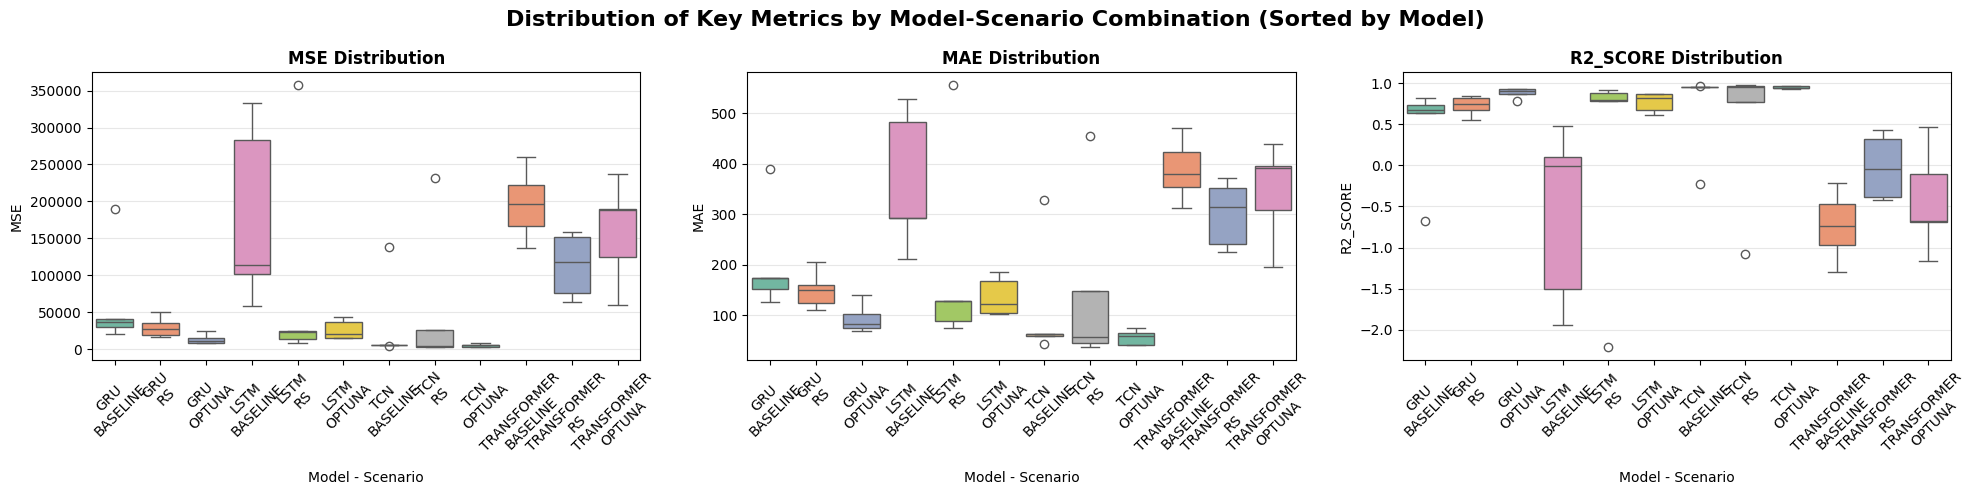


DETAILED BOXPLOT ANALYSIS - By Model-Scenario (Sorted by Model)



C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\1139141999.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sorted, x='model_scenario', y=metric, ax=ax, palette='husl', width=0.6)


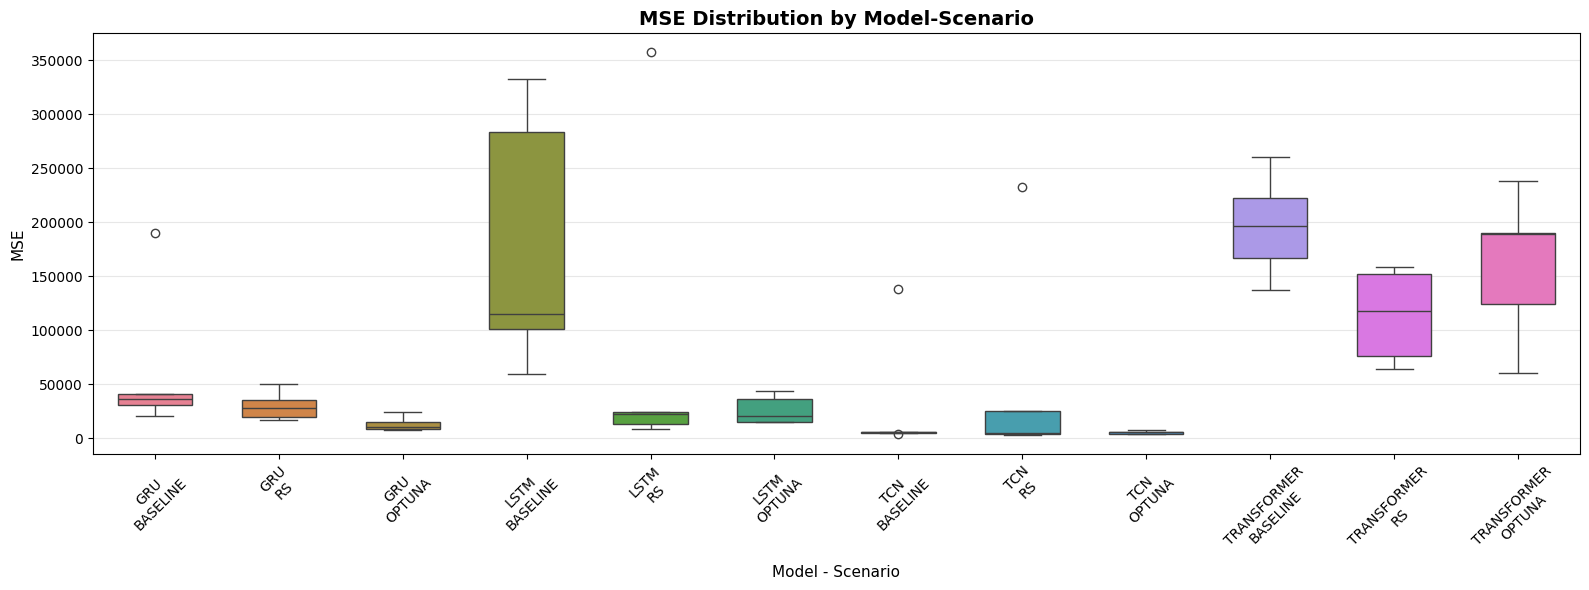

C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\1139141999.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sorted, x='model_scenario', y=metric, ax=ax, palette='husl', width=0.6)


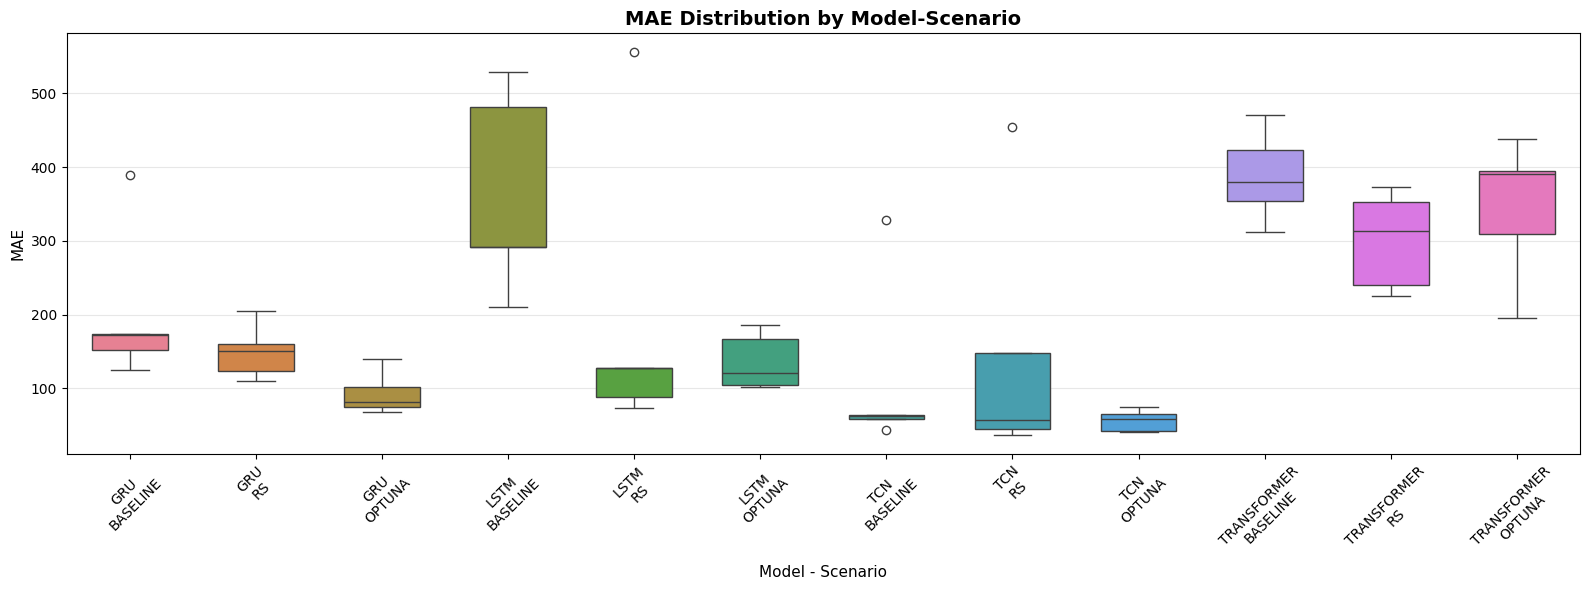

C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\1139141999.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sorted, x='model_scenario', y=metric, ax=ax, palette='husl', width=0.6)


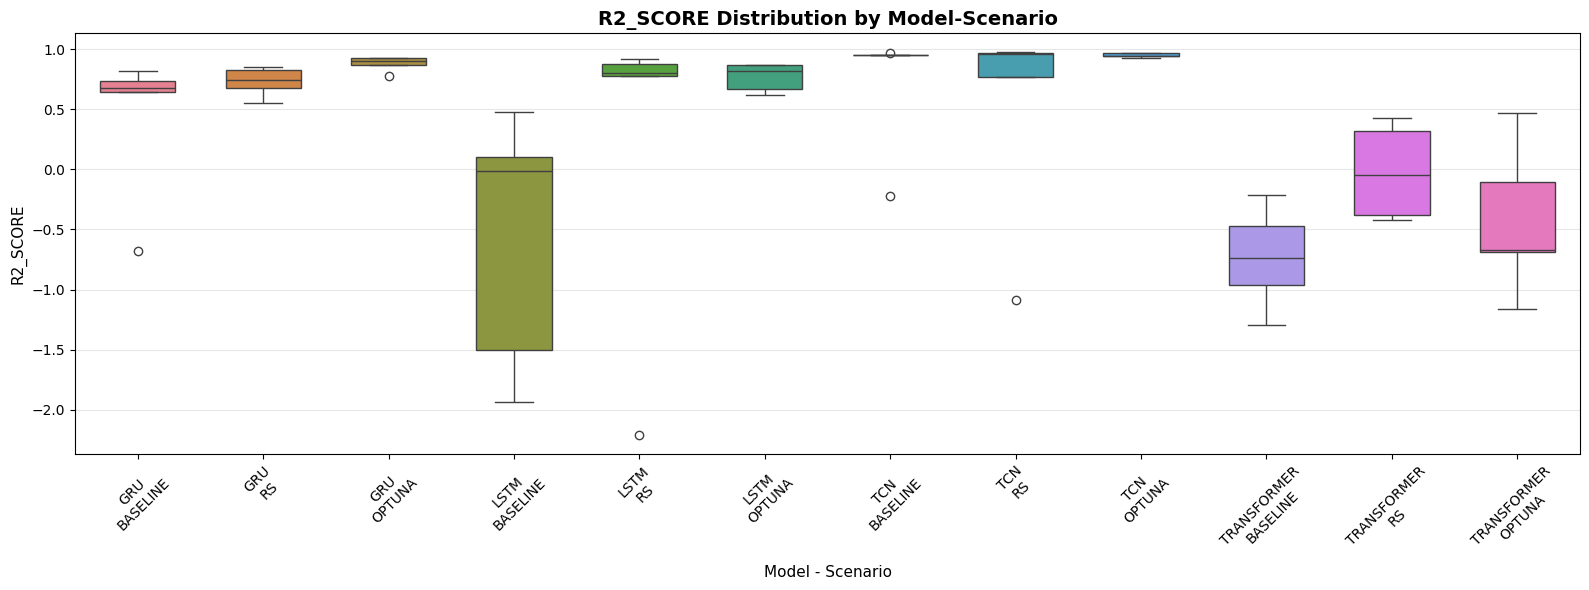

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for boxplots with sorted order
metrics_to_plot = ['mse', 'mae', 'r2_score']

# Create a sorted version of dataframe by model then scenario
model_order = {'gru': 0, 'lstm': 1, 'tcn': 2, 'transformer': 3}
scenario_order = {'baseline': 0, 'rs': 1, 'optuna': 2}

df_sorted = df.copy()
df_sorted['model_sort'] = df_sorted['model'].map(model_order)
df_sorted['scenario_sort'] = df_sorted['scenario'].map(scenario_order)
df_sorted = df_sorted.sort_values(['model_sort', 'scenario_sort'])

# Create model_scenario column with sorted order
df_sorted['model_scenario'] = df_sorted['model'].str.upper() + '\n' + df_sorted['scenario'].str.upper()

# Define the category order for proper x-axis ordering
model_scenario_order = []
for model in models_order:
    for scenario in scenarios_order:
        model_scenario_order.append(f"{model.upper()}\n{scenario.upper()}")

# Convert to categorical to maintain order
df_sorted['model_scenario'] = pd.Categorical(df_sorted['model_scenario'], categories=model_scenario_order, ordered=True)

# Create boxplots for three metrics
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Distribution of Key Metrics by Model-Scenario Combination (Sorted by Model)', fontsize=16, fontweight='bold')

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    
    # Create boxplot with sorted data
    sns.boxplot(data=df_sorted, x='model_scenario', y=metric, ax=ax, palette='Set2')
    
    # Customize subplot
    ax.set_title(f'{metric.upper()} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Model - Scenario', fontsize=10)
    ax.set_ylabel(metric.upper(), fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    
    # Rotate x-axis labels for better readability
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Create individual plots for better visibility
print("\n" + "="*80)
print("DETAILED BOXPLOT ANALYSIS - By Model-Scenario (Sorted by Model)")
print("="*80 + "\n")

for metric in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(16, 6))
    
    sns.boxplot(data=df_sorted, x='model_scenario', y=metric, ax=ax, palette='husl', width=0.6)
    
    ax.set_title(f'{metric.upper()} Distribution by Model-Scenario', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model - Scenario', fontsize=11)
    ax.set_ylabel(metric.upper(), fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

In [6]:
# Summary Statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80 + "\n")

summary_data = []
for group_info in group_tables:
    model = group_info['model']
    scenario = group_info['scenario']
    data = group_info['data']
    
    summary_data.append({
        'Model': model.upper(),
        'Scenario': scenario.upper(),
        'Count': len(data),
        'Best MSE': f"{data['mse'].min():.2f}",
        'Worst MSE': f"{data['mse'].max():.2f}",
        'Avg R²': f"{data['r2_score'].mean():.4f}"
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df)


SUMMARY STATISTICS



,Model,Scenario,Count,Best MSE,Worst MSE,Avg R²
0,GRU,BASELINE,5,20374.77,189822.42,0.4386
1,GRU,RS,5,16872.76,50074.42,0.7295
2,GRU,OPTUNA,5,7899.72,24530.23,0.8798
3,LSTM,BASELINE,5,59127.99,332647.46,-0.5731
4,LSTM,RS,5,8700.65,357016.57,0.2333
5,LSTM,OPTUNA,5,15130.40,43413.54,0.7672
6,TCN,BASELINE,5,4033.70,138519.09,0.7188
7,TCN,RS,5,3112.89,232357.14,0.5164
8,TCN,OPTUNA,5,3550.72,7866.86,0.9509
9,TRANSFORMER,BASELINE,5,137104.58,260397.07,-0.7367



BOXPLOT ANALYSIS - By Scenario (Baseline, RS, Optuna)



C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scenario_data, x='model', y=metric, ax=ax, palette='Set2')
C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label.get_text().upper() for label in ax.get_xticklabels()])
C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scenario_data, x='model', y=metric, ax=ax, palette='Set2')
C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:32:

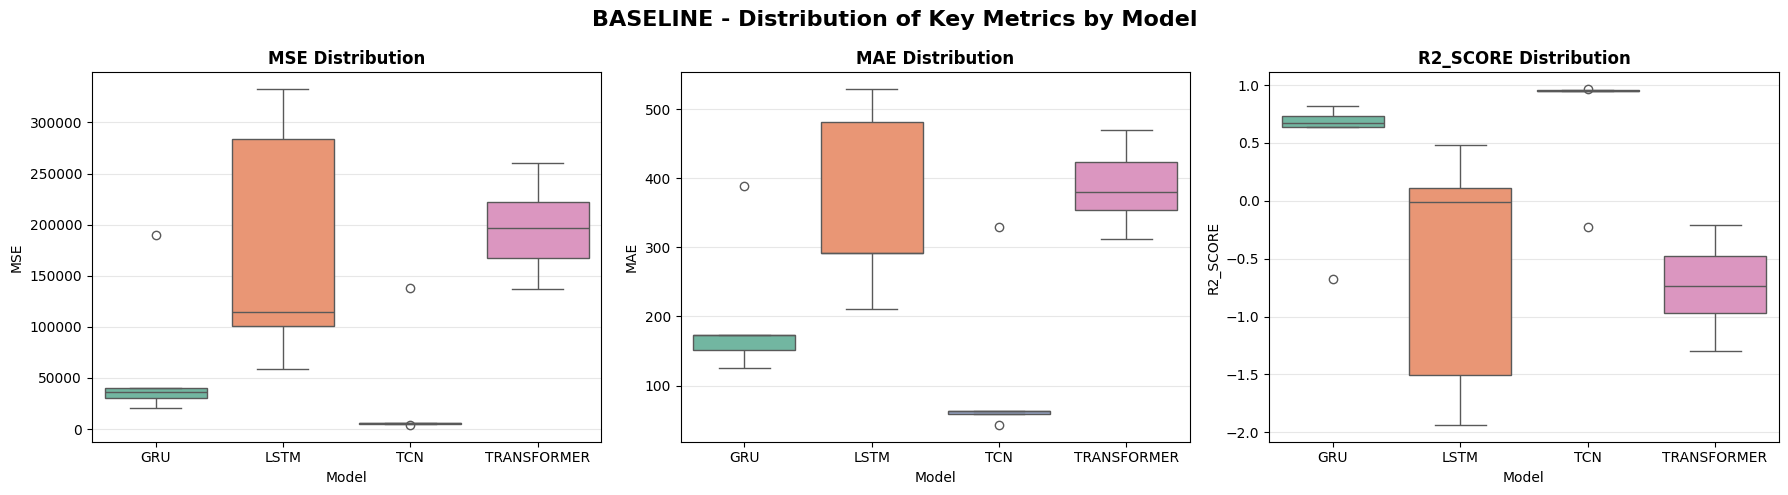

C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scenario_data, x='model', y=metric, ax=ax, palette='Set2')
C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label.get_text().upper() for label in ax.get_xticklabels()])
C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scenario_data, x='model', y=metric, ax=ax, palette='Set2')
C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:32:

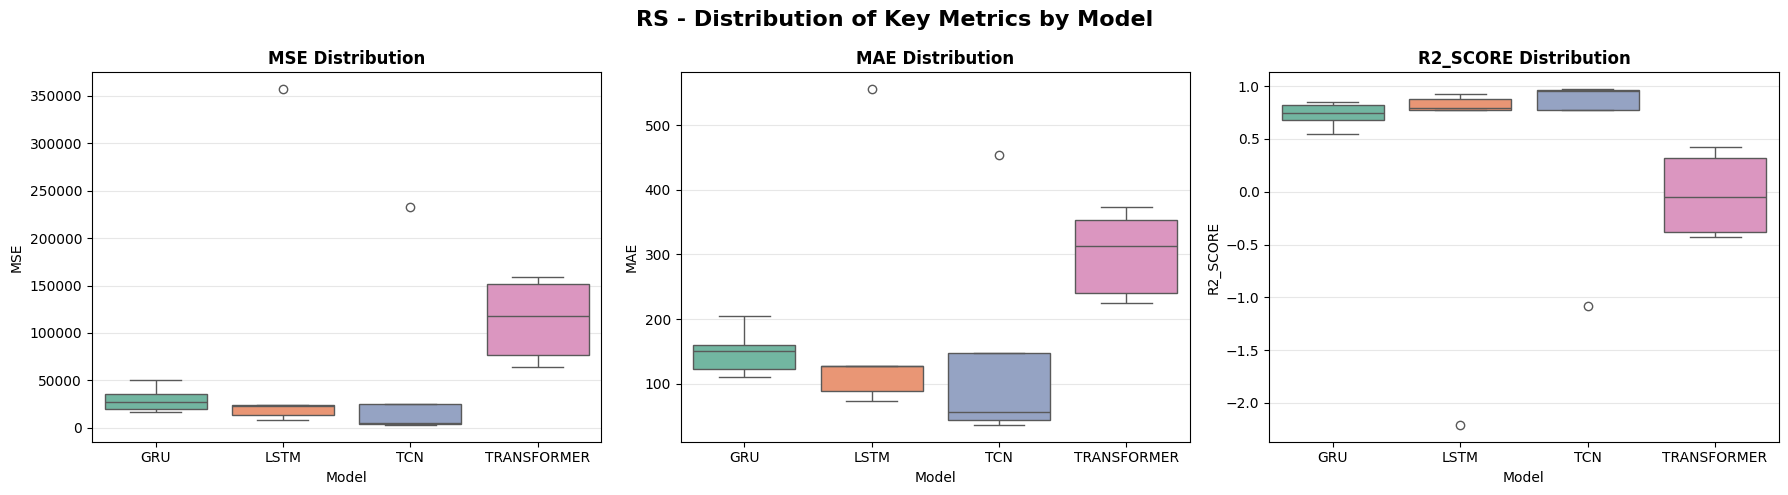

C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scenario_data, x='model', y=metric, ax=ax, palette='Set2')
C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label.get_text().upper() for label in ax.get_xticklabels()])
C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scenario_data, x='model', y=metric, ax=ax, palette='Set2')
C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:32:

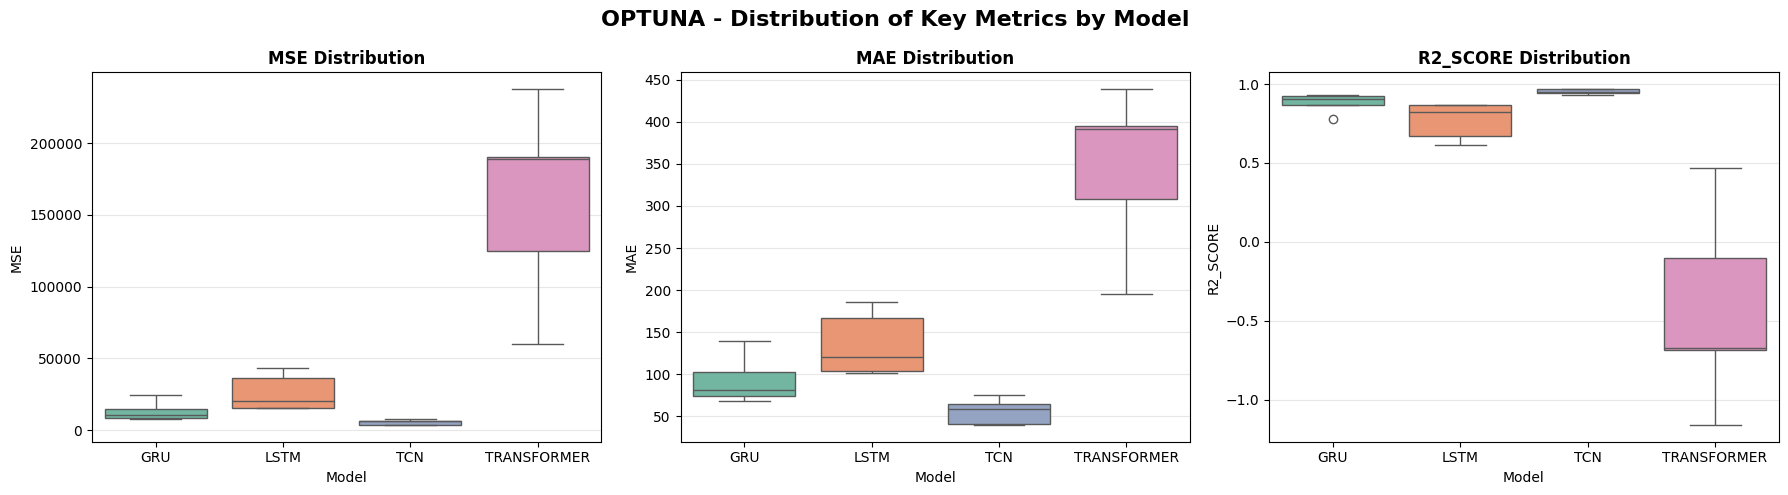


DETAILED BOXPLOT ANALYSIS - By Scenario



C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scenario_data, x='model', y=metric, ax=ax, palette='husl', width=0.6)
C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label.get_text().upper() for label in ax.get_xticklabels()])


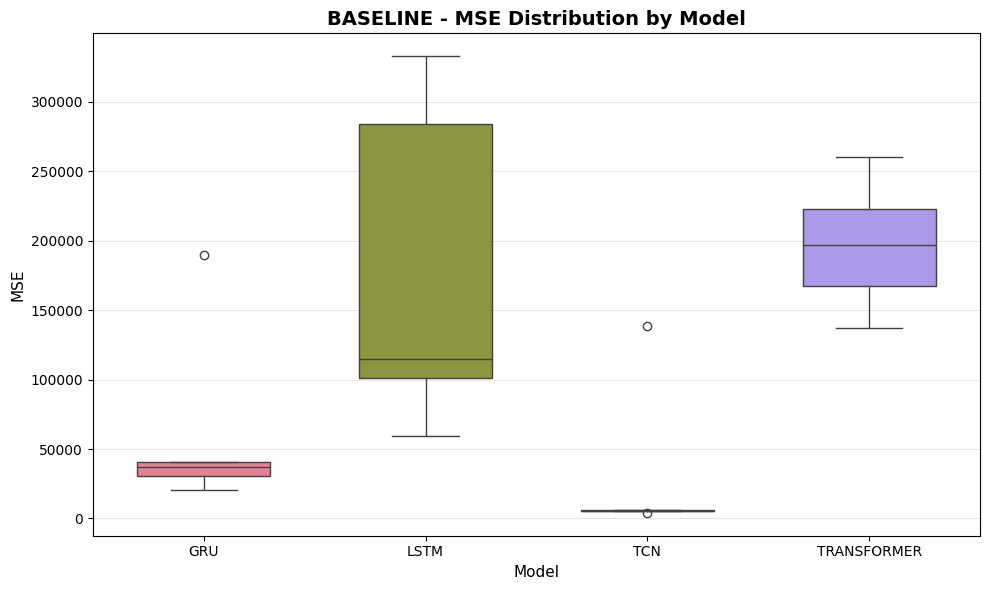

C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scenario_data, x='model', y=metric, ax=ax, palette='husl', width=0.6)
C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label.get_text().upper() for label in ax.get_xticklabels()])


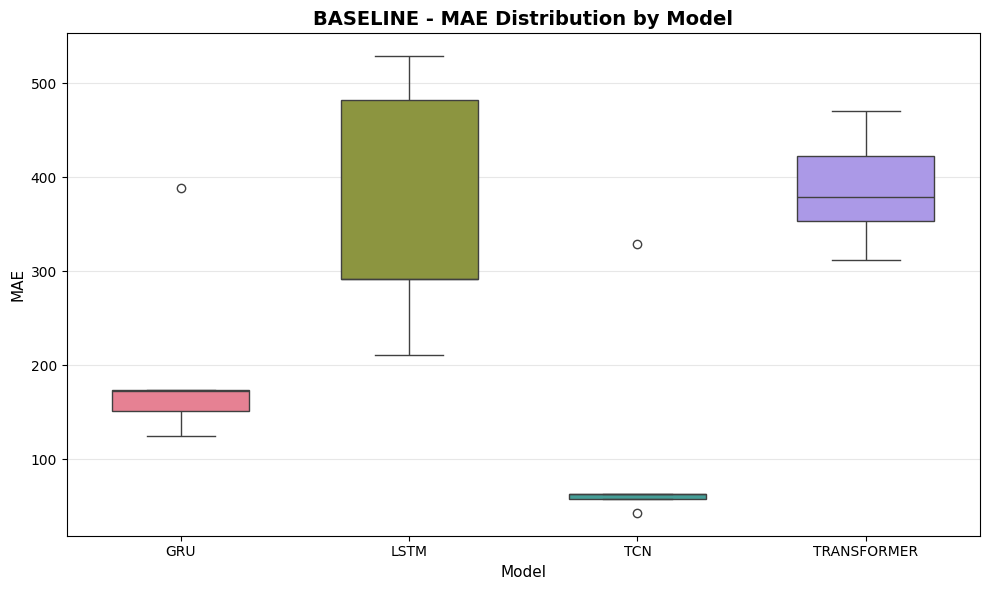

C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scenario_data, x='model', y=metric, ax=ax, palette='husl', width=0.6)
C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label.get_text().upper() for label in ax.get_xticklabels()])


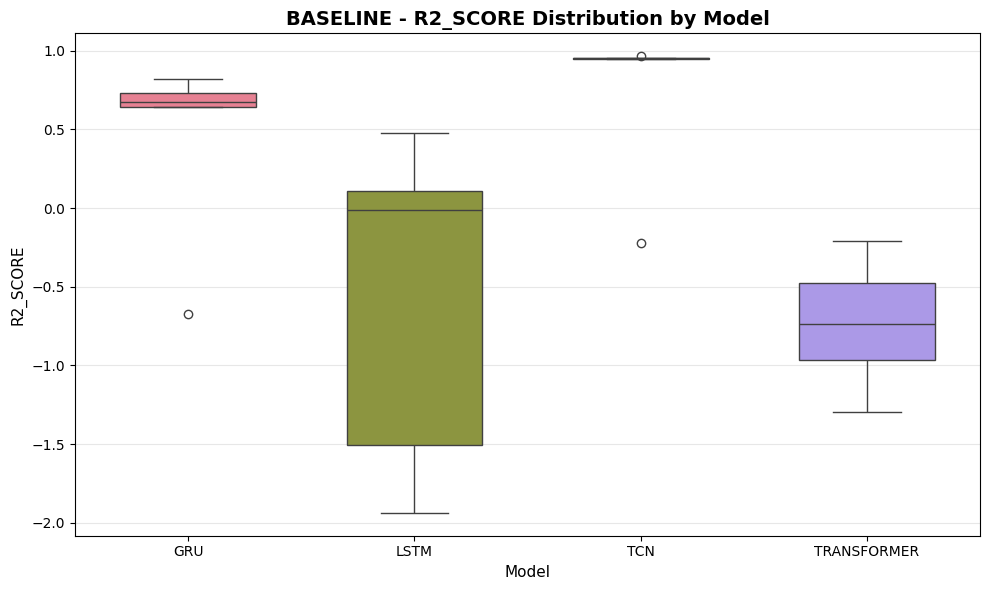

C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scenario_data, x='model', y=metric, ax=ax, palette='husl', width=0.6)
C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label.get_text().upper() for label in ax.get_xticklabels()])


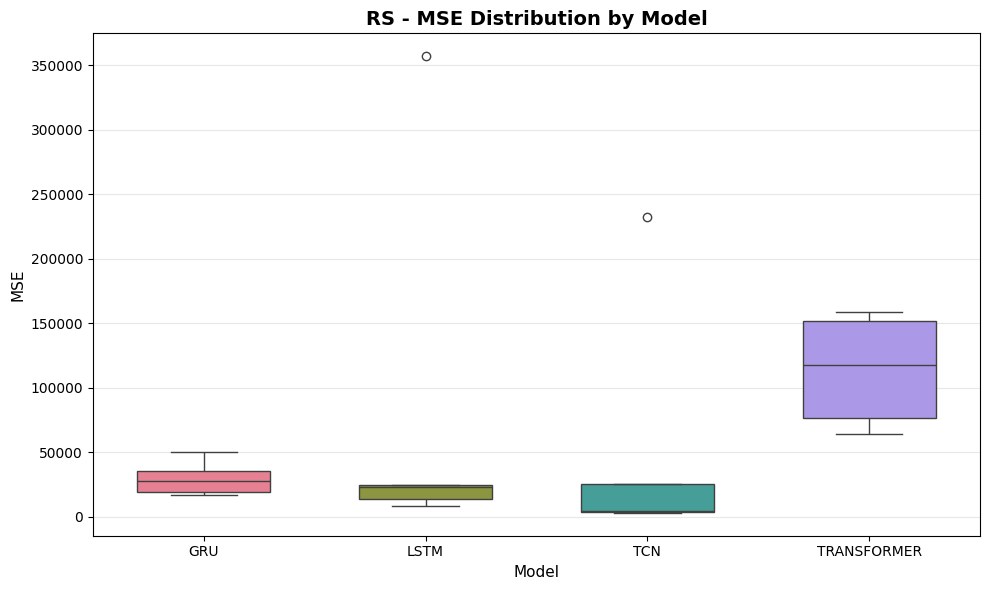

C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scenario_data, x='model', y=metric, ax=ax, palette='husl', width=0.6)
C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label.get_text().upper() for label in ax.get_xticklabels()])


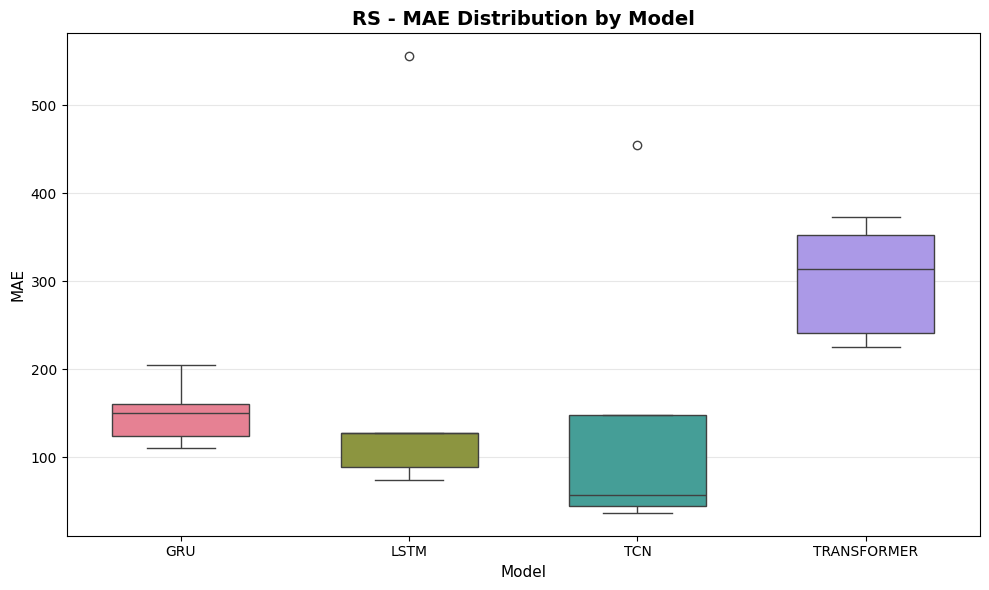

C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scenario_data, x='model', y=metric, ax=ax, palette='husl', width=0.6)
C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label.get_text().upper() for label in ax.get_xticklabels()])


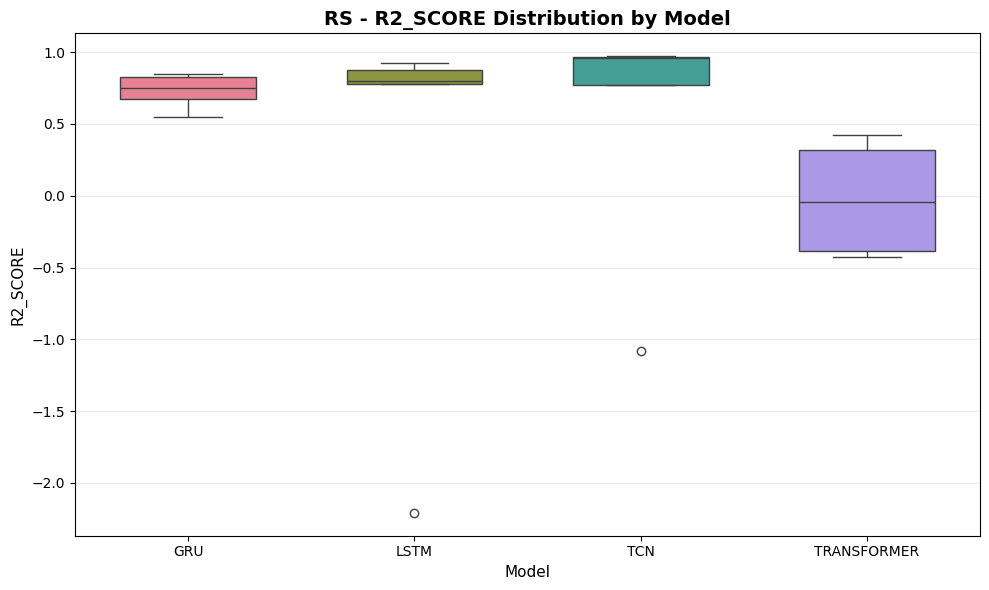

C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scenario_data, x='model', y=metric, ax=ax, palette='husl', width=0.6)
C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label.get_text().upper() for label in ax.get_xticklabels()])


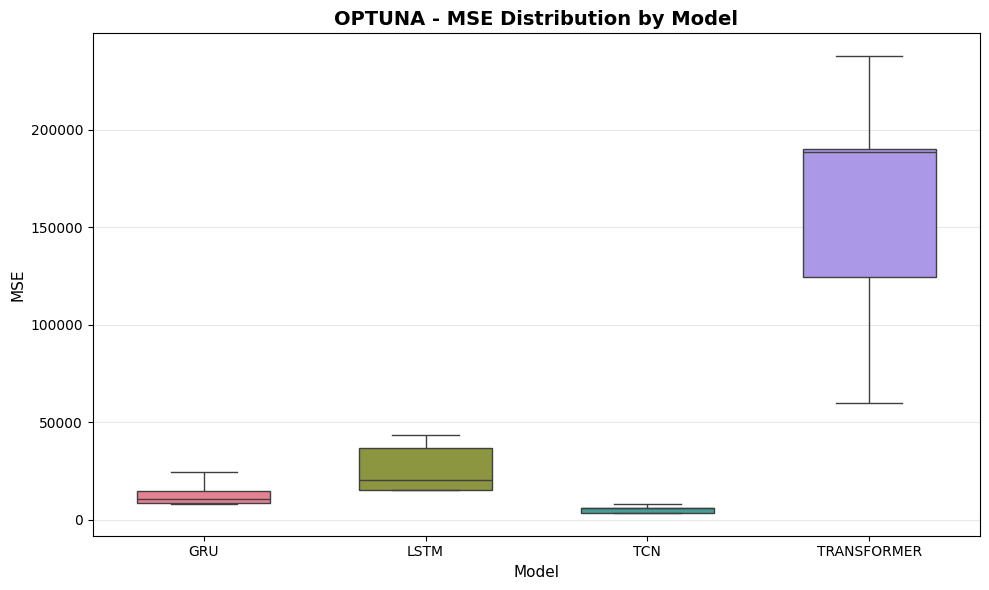

C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scenario_data, x='model', y=metric, ax=ax, palette='husl', width=0.6)
C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label.get_text().upper() for label in ax.get_xticklabels()])


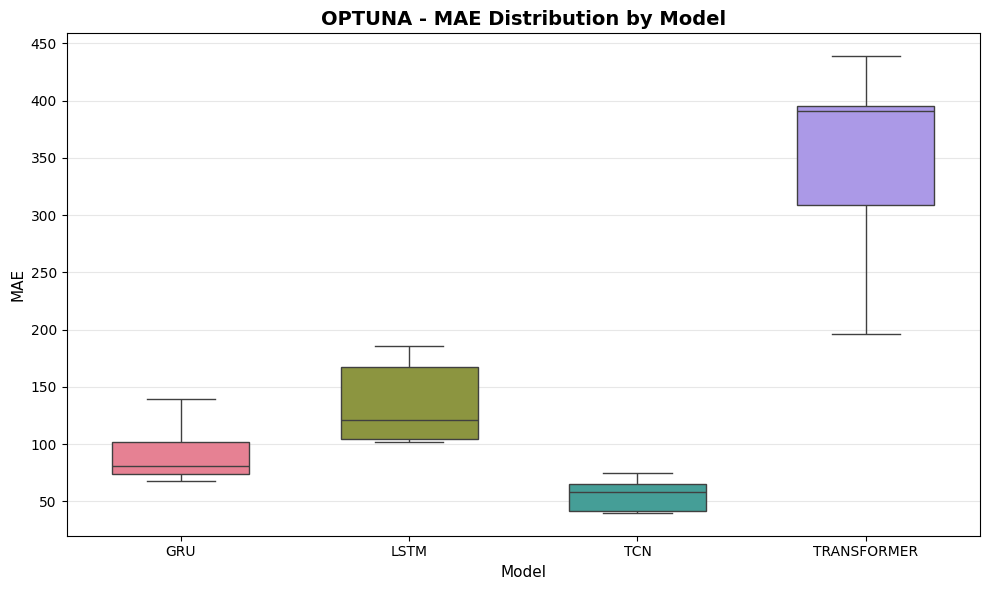

C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scenario_data, x='model', y=metric, ax=ax, palette='husl', width=0.6)
C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\2921903648.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label.get_text().upper() for label in ax.get_xticklabels()])


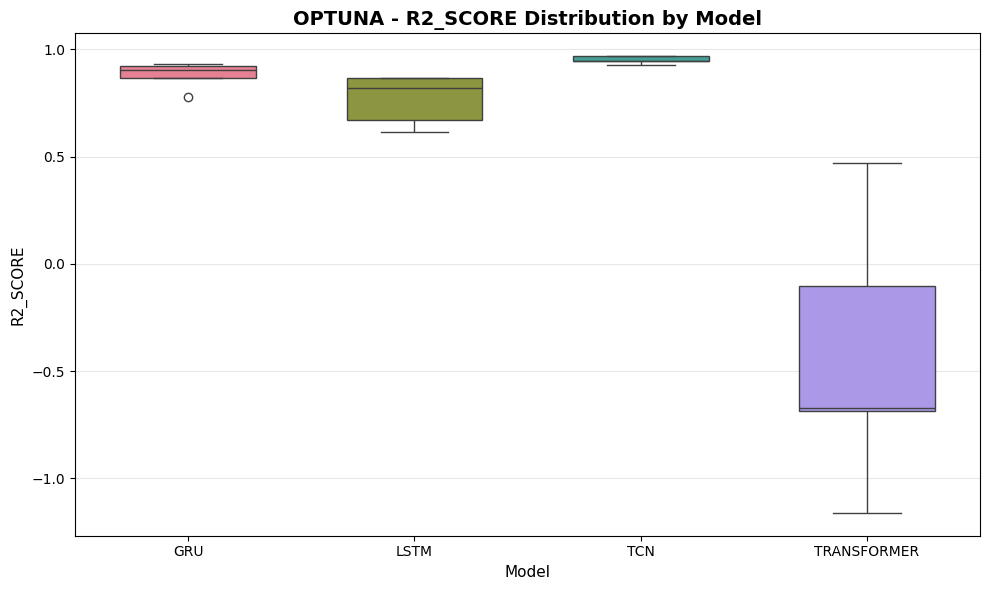

In [7]:
# Boxplots by Scenario (Baseline, RS, Optuna) with Models on X-axis
print("\n" + "="*80)
print("BOXPLOT ANALYSIS - By Scenario (Baseline, RS, Optuna)")
print("="*80 + "\n")

# Create model categorical column for proper ordering
model_category_order = ['gru', 'lstm', 'tcn', 'transformer']
df['model'] = pd.Categorical(df['model'], categories=model_category_order, ordered=True)

# Create boxplots for each scenario
for scenario in scenarios_order:
    # Filter data for this scenario
    scenario_data = df[df['scenario'] == scenario].copy()
    
    # Create combined plot for 3 metrics
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{scenario.upper()} - Distribution of Key Metrics by Model', fontsize=16, fontweight='bold')
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx]
        
        # Create boxplot with models on x-axis
        sns.boxplot(data=scenario_data, x='model', y=metric, ax=ax, palette='Set2')
        
        # Customize subplot
        ax.set_title(f'{metric.upper()} Distribution', fontsize=12, fontweight='bold')
        ax.set_xlabel('Model', fontsize=10)
        ax.set_ylabel(metric.upper(), fontsize=10)
        ax.grid(axis='y', alpha=0.3)
        
        # Capitalize x-axis labels
        ax.set_xticklabels([label.get_text().upper() for label in ax.get_xticklabels()])
    
    plt.tight_layout()
    plt.show()

# Create individual detailed plots for each scenario
print("\n" + "="*80)
print("DETAILED BOXPLOT ANALYSIS - By Scenario")
print("="*80 + "\n")

for scenario in scenarios_order:
    # Filter data for this scenario
    scenario_data = df[df['scenario'] == scenario].copy()
    
    for metric in metrics_to_plot:
        fig, ax = plt.subplots(figsize=(10, 6))
        
        sns.boxplot(data=scenario_data, x='model', y=metric, ax=ax, palette='husl', width=0.6)
        
        ax.set_title(f'{scenario.upper()} - {metric.upper()} Distribution by Model', fontsize=14, fontweight='bold')
        ax.set_xlabel('Model', fontsize=11)
        ax.set_ylabel(metric.upper(), fontsize=11)
        ax.grid(axis='y', alpha=0.3)
        
        # Capitalize x-axis labels
        ax.set_xticklabels([label.get_text().upper() for label in ax.get_xticklabels()])
        
        plt.tight_layout()
        plt.show()

In [10]:
# Check available columns
print("Available columns in ALL_METRICS.csv:")
print(df.columns.tolist())
print(f"\nDataset shape: {df.shape}")
print(f"\nFirst few rows:")
display(df.head(3))


Available columns in ALL_METRICS.csv:
['timestamp', 'model_name', 'seed', 'mse', 'mae', 'rmse', 'mape', 'r2_score', 'picp', 'mpiw', 'winkler_score', 'training_time_s', 'testing_time_s', 'hpo_trial_s', 'hpo_time_s', 'model', 'scenario']

Dataset shape: (60, 17)

First few rows:


,timestamp,model_name,seed,mse,mae,rmse,mape,r2_score,picp,mpiw,winkler_score,training_time_s,testing_time_s,hpo_trial_s,hpo_time_s,model,scenario
0,2025-11-16 21:13:39,gru_baseline_42,42,36724.369588,172.803324,191.636034,0.024130,0.675851,0,0,0,17.0913,0.1047,0,0.0,gru,baseline
1,2025-11-16 21:14:05,lstm_baseline_42,42,332647.464083,528.904819,576.755983,0.073539,-1.936129,0,0,0,8.6057,0.1211,0,0.0,lstm,baseline
2,2025-11-16 21:15:43,tcn_baseline_42,42,5700.487624,62.937167,75.501574,0.008900,0.949684,0,0,0,85.9564,0.1341,0,0.0,tcn,baseline


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create model_scenario_seed column for easier visualization
df['model_scenario_seed'] = df['model_name']
df = df.sort_values(['model', 'scenario', 'seed'])

print("\n" + "="*80)
print("TIMING ANALYSIS: Training Time, Testing Time, and HPO Time")
print("="*80 + "\n")

# Summary statistics for timing metrics
print("Summary Statistics for Timing Metrics (seconds):\n")

print("TRAINING TIME (training_time_s):")
training_stats = df.groupby('scenario')['training_time_s'].agg(['count', 'mean', 'std', 'min', 'max'])
print(training_stats.round(4))

print("\n\nTESTING TIME (testing_time_s):")
testing_stats = df.groupby('scenario')['testing_time_s'].agg(['count', 'mean', 'std', 'min', 'max'])
print(testing_stats.round(4))

print("\n\nHPO TIME (hpo_time_s):")
hpo_stats = df.groupby('scenario')['hpo_time_s'].agg(['count', 'mean', 'std', 'min', 'max'])
print(hpo_stats.round(4))

print("\n\nTOTAL EXECUTION TIME (training + testing + hpo):")
df['total_time_s'] = df['training_time_s'] + df['testing_time_s'] + df['hpo_time_s']
total_stats = df.groupby('scenario')['total_time_s'].agg(['count', 'mean', 'std', 'min', 'max'])
print(total_stats.round(4))

# By model
print("\n\nTRAINING TIME BY MODEL:")
training_by_model = df.groupby('model')['training_time_s'].agg(['count', 'mean', 'std', 'min', 'max'])
print(training_by_model.round(4))

print("\n\nTESTING TIME BY MODEL:")
testing_by_model = df.groupby('model')['testing_time_s'].agg(['count', 'mean', 'std', 'min', 'max'])
print(testing_by_model.round(4))

print("\n\nHPO TIME BY MODEL:")
hpo_by_model = df.groupby('model')['hpo_time_s'].agg(['count', 'mean', 'std', 'min', 'max'])
print(hpo_by_model.round(4))



TIMING ANALYSIS: Training Time, Testing Time, and HPO Time

Summary Statistics for Timing Metrics (seconds):

TRAINING TIME (training_time_s):
          count      mean       std      min       max
scenario                                              
baseline     20   30.6731   23.0010   6.8414   88.1961
optuna       20  161.3395  167.3758  17.8729  656.1109
rs           20  196.5593  160.1847  34.5151  554.1697


TESTING TIME (testing_time_s):
          count    mean     std     min     max
scenario                                       
baseline     20  0.1264  0.0218  0.0939  0.1555
optuna       20  0.6766  0.6007  0.2001  2.2953
rs           20  1.1813  0.7803  0.4198  2.9891


HPO TIME (hpo_time_s):
          count       mean        std        min         max
scenario                                                    
baseline     20     0.0000     0.0000     0.0000      0.0000
optuna       20  4866.8043  1728.9895  2415.0158   9592.1751
rs           20  6943.3360  4101.5998  

C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\1216121958.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot([training_by_model_df[model] for model in models_order], labels=models_order, patch_artist=True)
C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\1216121958.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot([training_by_scenario_df[scenario] for scenario in scenarios_order], labels=scenarios_order, patch_artist=True)
C:\Users\Alden\AppData\Local\Temp\ipykernel_6484\1216121958.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = ax3.boxplot([testing_by_model_df[mod

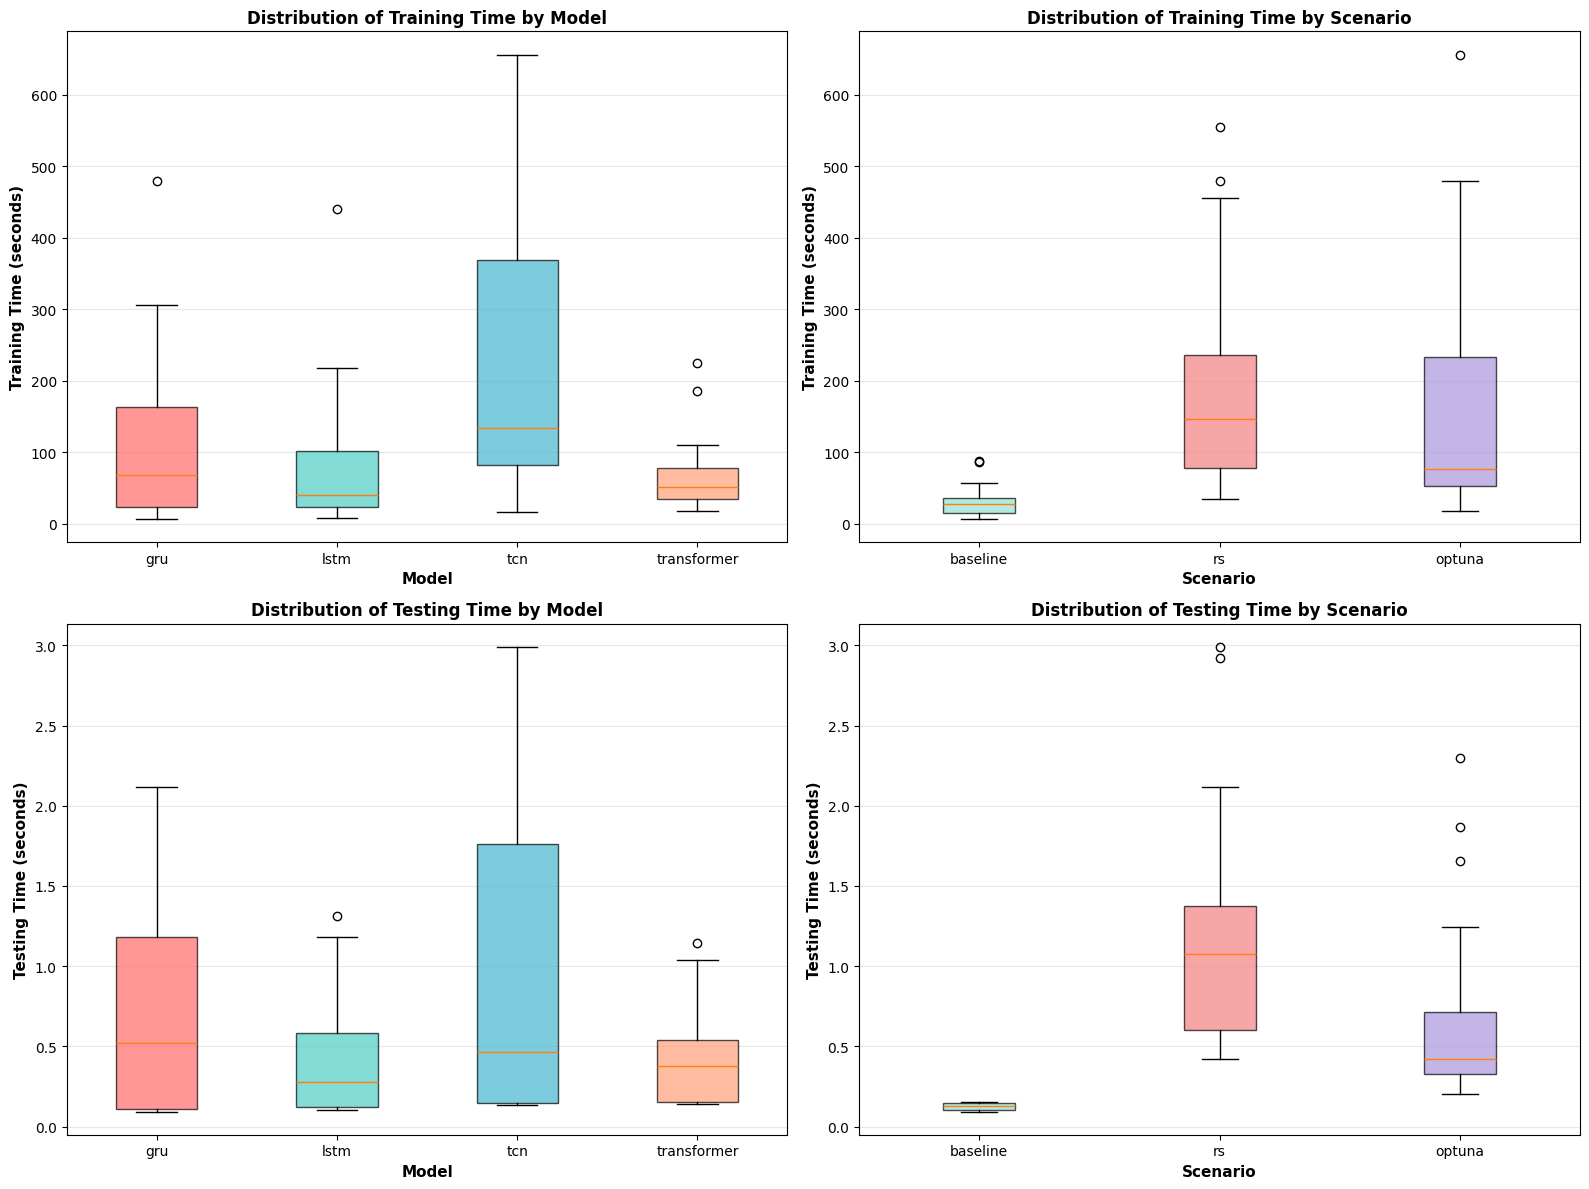


✓ Training and Testing Time Distributions Generated


In [12]:
# Visualization 1: Training Time by Model-Scenario
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Training Time by Model (all scenarios combined)
ax1 = axes[0, 0]
models_order = ['gru', 'lstm', 'tcn', 'transformer']
training_by_model_df = df.groupby('model')['training_time_s'].apply(list).reindex(models_order)
bp1 = ax1.boxplot([training_by_model_df[model] for model in models_order], labels=models_order, patch_artist=True)
for patch, color in zip(bp1['boxes'], ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.set_ylabel('Training Time (seconds)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Model', fontsize=11, fontweight='bold')
ax1.set_title('Distribution of Training Time by Model', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# 2. Training Time by Scenario (all models combined)
ax2 = axes[0, 1]
scenarios_order = ['baseline', 'rs', 'optuna']
training_by_scenario_df = df.groupby('scenario')['training_time_s'].apply(list).reindex(scenarios_order)
bp2 = ax2.boxplot([training_by_scenario_df[scenario] for scenario in scenarios_order], labels=scenarios_order, patch_artist=True)
for patch, color in zip(bp2['boxes'], ['#95E1D3', '#F38181', '#AA96DA']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_ylabel('Training Time (seconds)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Scenario', fontsize=11, fontweight='bold')
ax2.set_title('Distribution of Training Time by Scenario', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# 3. Testing Time by Model
ax3 = axes[1, 0]
testing_by_model_df = df.groupby('model')['testing_time_s'].apply(list).reindex(models_order)
bp3 = ax3.boxplot([testing_by_model_df[model] for model in models_order], labels=models_order, patch_artist=True)
for patch, color in zip(bp3['boxes'], ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_ylabel('Testing Time (seconds)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Model', fontsize=11, fontweight='bold')
ax3.set_title('Distribution of Testing Time by Model', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# 4. Testing Time by Scenario
ax4 = axes[1, 1]
testing_by_scenario_df = df.groupby('scenario')['testing_time_s'].apply(list).reindex(scenarios_order)
bp4 = ax4.boxplot([testing_by_scenario_df[scenario] for scenario in scenarios_order], labels=scenarios_order, patch_artist=True)
for patch, color in zip(bp4['boxes'], ['#95E1D3', '#F38181', '#AA96DA']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax4.set_ylabel('Testing Time (seconds)', fontsize=11, fontweight='bold')
ax4.set_xlabel('Scenario', fontsize=11, fontweight='bold')
ax4.set_title('Distribution of Testing Time by Scenario', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Training and Testing Time Distributions Generated")


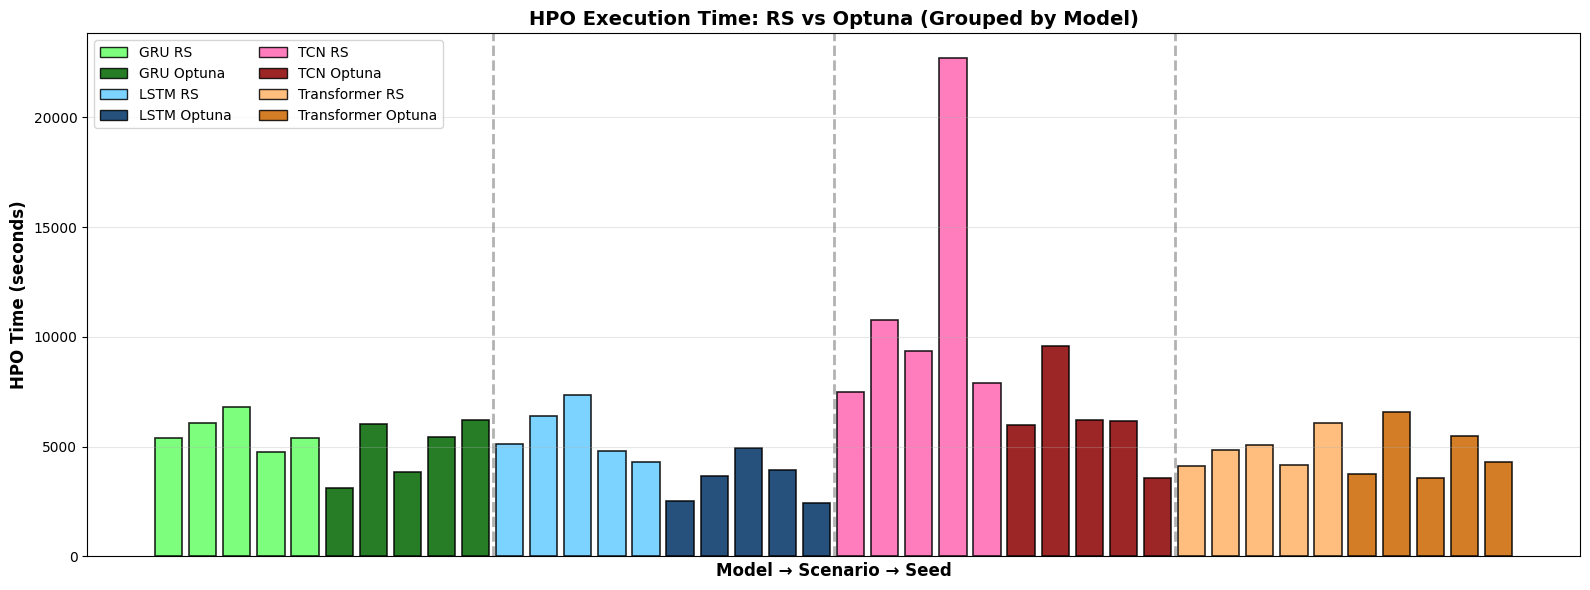


✓ HPO Time Visualization Generated (RS vs Optuna with Custom Colors - Sorted by Model)


In [19]:
# Visualization 2: HPO Time Comparison (RS vs Optuna) with Custom Colors - Sorted by Model
fig, ax = plt.subplots(figsize=(16, 6))

# Define custom colors for each model-scenario combination with better contrast
color_map = {
    ('gru', 'rs'): '#66FF66',           # Bright green for GRU RS
    ('gru', 'optuna'): '#006600',       # Dark green for GRU Optuna
    ('lstm', 'rs'): '#66CCFF',          # Bright blue for LSTM RS
    ('lstm', 'optuna'): '#003366',      # Dark blue for LSTM Optuna
    ('tcn', 'rs'): '#FF66B2',           # Bright pink for TCN RS
    ('tcn', 'optuna'): '#8B0000',       # Dark red for TCN Optuna
    ('transformer', 'rs'): '#FFB366',   # Bright orange for Transformer RS
    ('transformer', 'optuna'): '#CC6600' # Dark orange for Transformer Optuna
}

# Prepare data sorted by model then scenario then seed
df_hpo = df[df['scenario'].isin(['rs', 'optuna'])].copy()
scenario_order_num = {'rs': 0, 'optuna': 1}
df_hpo['scenario_num'] = df_hpo['scenario'].map(scenario_order_num)
model_order_num = {'gru': 0, 'lstm': 1, 'tcn': 2, 'transformer': 3}
df_hpo['model_num'] = df_hpo['model'].map(model_order_num)
df_hpo_sorted = df_hpo.sort_values(['model_num', 'scenario_num', 'seed']).reset_index(drop=True)

x_pos = np.arange(len(df_hpo_sorted))
colors = [color_map[(model, scenario)] for model, scenario in zip(df_hpo_sorted['model'], df_hpo_sorted['scenario'])]
bars = ax.bar(x_pos, df_hpo_sorted['hpo_time_s'], color=colors, alpha=0.85, edgecolor='black', linewidth=1.2)

# Add separator lines between models
prev_model = None
for i, model in enumerate(df_hpo_sorted['model']):
    if prev_model is not None and model != prev_model:
        ax.axvline(x=i-0.5, color='gray', linestyle='--', linewidth=2, alpha=0.6)
    prev_model = model

ax.set_ylabel('HPO Time (seconds)', fontsize=12, fontweight='bold')
ax.set_xlabel('Model → Scenario → Seed', fontsize=12, fontweight='bold')
ax.set_title('HPO Execution Time: RS vs Optuna (Grouped by Model)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticks([])

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#66FF66', alpha=0.85, edgecolor='black', label='GRU RS'),
    Patch(facecolor='#006600', alpha=0.85, edgecolor='black', label='GRU Optuna'),
    Patch(facecolor='#66CCFF', alpha=0.85, edgecolor='black', label='LSTM RS'),
    Patch(facecolor='#003366', alpha=0.85, edgecolor='black', label='LSTM Optuna'),
    Patch(facecolor='#FF66B2', alpha=0.85, edgecolor='black', label='TCN RS'),
    Patch(facecolor='#8B0000', alpha=0.85, edgecolor='black', label='TCN Optuna'),
    Patch(facecolor='#FFB366', alpha=0.85, edgecolor='black', label='Transformer RS'),
    Patch(facecolor='#CC6600', alpha=0.85, edgecolor='black', label='Transformer Optuna')
]
ax.legend(handles=legend_elements, fontsize=10, loc='upper left', ncol=2)

plt.tight_layout()
plt.show()

print("\n✓ HPO Time Visualization Generated (RS vs Optuna with Custom Colors - Sorted by Model)")



TIME COMPOSITION VISUALIZATION



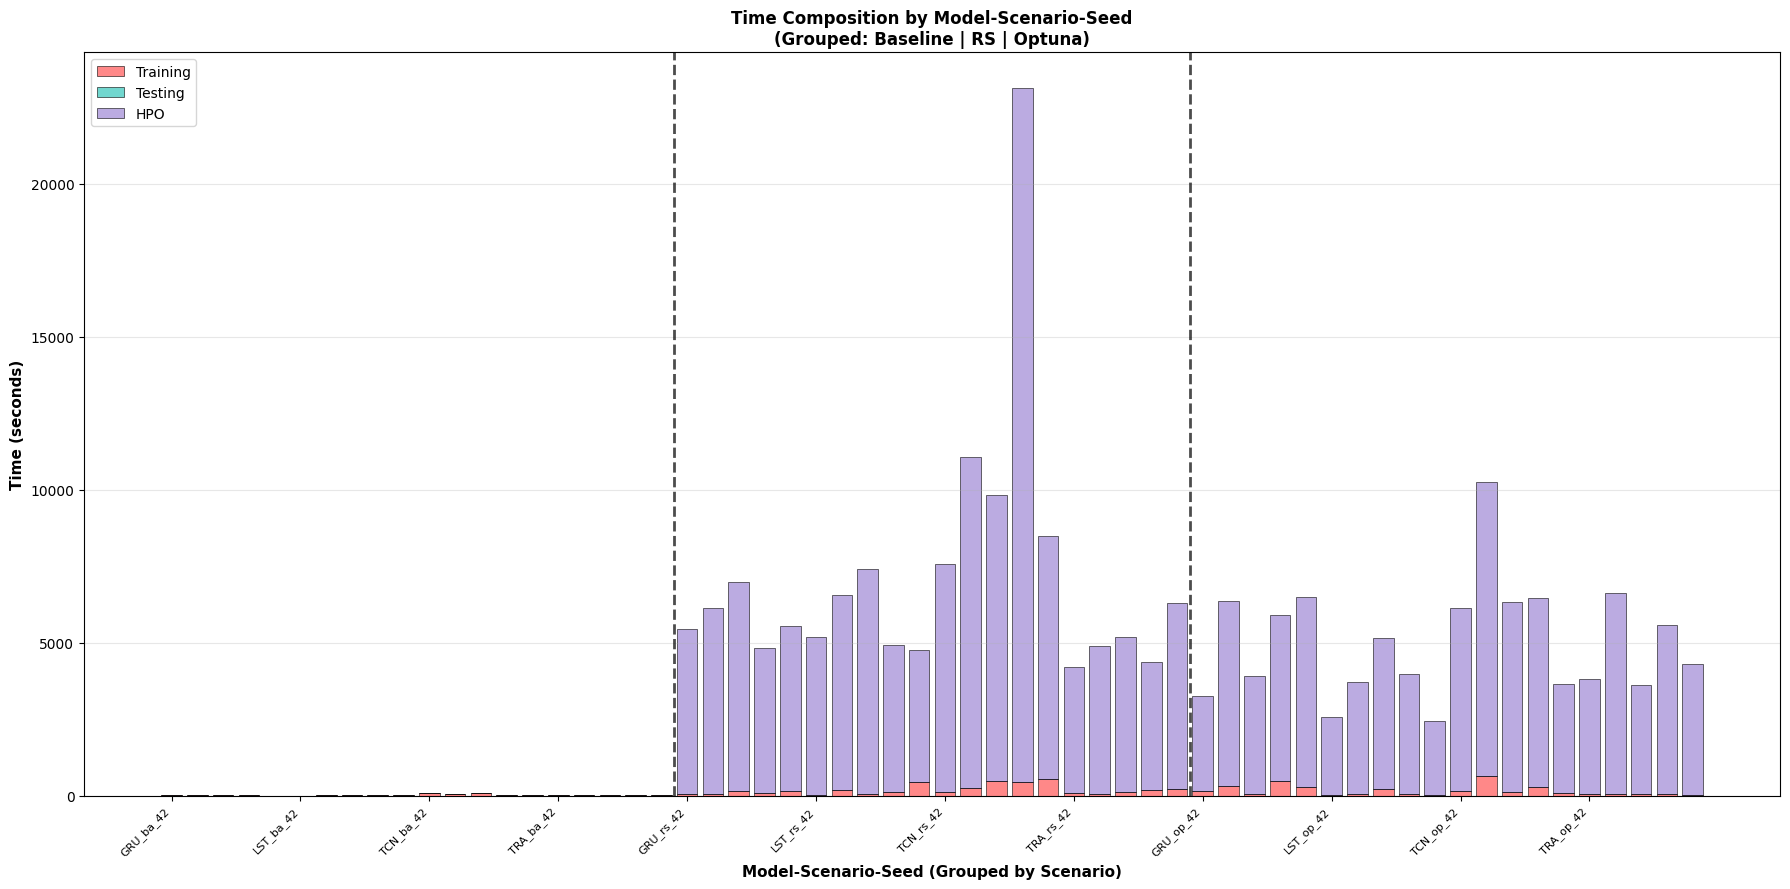


✓ Time Composition Visualization Generated


In [20]:
# Visualization: Time Composition by Model-Scenario-Seed (Grouped by Scenario)
print("\n" + "="*80)
print("TIME COMPOSITION VISUALIZATION")
print("="*80 + "\n")

# Configure figure size
figsize = (18, 9)  # Easily adjustable parameter

fig, ax = plt.subplots(figsize=figsize)

# Sort data: baseline first, then rs, then optuna
scenario_order_num = {'baseline': 0, 'rs': 1, 'optuna': 2}
model_order_num = {'gru': 0, 'lstm': 1, 'tcn': 2, 'transformer': 3}
df['scenario_num'] = df['scenario'].map(scenario_order_num)
df['model_num'] = df['model'].map(model_order_num)
df_display = df.sort_values(['scenario_num', 'model_num', 'seed']).reset_index(drop=True)

x_pos = np.arange(len(df_display))
labels = [f"{row['model'].upper()[:3]}_{row['scenario'][:2]}_{int(row['seed'])}" for _, row in df_display.iterrows()]

# Stacked bar chart - Total time by model_scenario_seed, grouped by scenario (baseline, rs, optuna)
bars1 = ax.bar(x_pos, df_display['training_time_s'], label='Training', alpha=0.8, color='#FF6B6B', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x_pos, df_display['testing_time_s'], bottom=df_display['training_time_s'], 
                label='Testing', alpha=0.8, color='#4ECDC4', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x_pos, df_display['hpo_time_s'], 
                bottom=df_display['training_time_s']+df_display['testing_time_s'],
                label='HPO', alpha=0.8, color='#AA96DA', edgecolor='black', linewidth=0.5)

# Add scenario separators
baseline_count = len(df_display[df_display['scenario'] == 'baseline'])
baseline_rs_count = baseline_count + len(df_display[df_display['scenario'] == 'rs'])
ax.axvline(x=baseline_count-0.5, color='black', linestyle='--', linewidth=2, alpha=0.7)
ax.axvline(x=baseline_rs_count-0.5, color='black', linestyle='--', linewidth=2, alpha=0.7)

ax.set_xticks(x_pos[::5])  # Show every 5th label for clarity
ax.set_xticklabels(labels[::5], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Time (seconds)', fontsize=11, fontweight='bold')
ax.set_xlabel('Model-Scenario-Seed (Grouped by Scenario)', fontsize=11, fontweight='bold')
ax.set_title('Time Composition by Model-Scenario-Seed\n(Grouped: Baseline | RS | Optuna)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Time Composition Visualization Generated")


In [15]:
# Comprehensive Timing Summary Table
print("\n" + "="*80)
print("COMPREHENSIVE TIMING SUMMARY TABLE")
print("="*80 + "\n")

# Create summary table
timing_summary = []

for model in models_order:
    for scenario in scenarios_order:
        subset = df[(df['model'] == model) & (df['scenario'] == scenario)]
        
        training_mean = subset['training_time_s'].mean()
        testing_mean = subset['testing_time_s'].mean()
        hpo_mean = subset['hpo_time_s'].mean()
        total_mean = training_mean + testing_mean + hpo_mean
        
        training_std = subset['training_time_s'].std()
        testing_std = subset['testing_time_s'].std()
        hpo_std = subset['hpo_time_s'].std()
        
        timing_summary.append({
            'Model': model.upper(),
            'Scenario': scenario.upper(),
            'Training (s)': f"{training_mean:.2f}±{training_std:.2f}",
            'Testing (s)': f"{testing_mean:.4f}±{testing_std:.4f}",
            'HPO (s)': f"{hpo_mean:.2f}±{hpo_std:.2f}",
            'Total (s)': f"{total_mean:.2f}"
        })

timing_summary_df = pd.DataFrame(timing_summary)
print("Mean ± Std for all timing metrics:\n")
display(timing_summary_df)

# Table for each model across all scenarios
print("\n\n" + "="*80)
print("TIMING COMPARISON: All Seeds for Each Model-Scenario")
print("="*80 + "\n")

for model in models_order:
    print(f"\n{model.upper()} Model - All Seeds, All Scenarios:\n")
    model_data = df[df['model'] == model][['model_name', 'seed', 'scenario', 'training_time_s', 'testing_time_s', 'hpo_time_s']].sort_values(['scenario', 'seed'])
    model_data['total_time_s'] = model_data['training_time_s'] + model_data['testing_time_s'] + model_data['hpo_time_s']
    display(model_data.reset_index(drop=True))
    display(Markdown("---"))



COMPREHENSIVE TIMING SUMMARY TABLE

Mean ± Std for all timing metrics:



,Model,Scenario,Training (s),Testing (s),HPO (s),Total (s)
0,GRU,BASELINE,16.00±9.02,0.1026±0.0060,0.00±0.00,16.10
1,GRU,RS,106.71±53.78,0.9845±0.6810,5683.99±798.94,5791.68
2,GRU,OPTUNA,255.77±158.30,1.1144±0.6960,4925.65±1379.05,5182.54
3,LSTM,BASELINE,17.01±8.31,0.1106±0.0093,0.00±0.00,17.12
4,LSTM,RS,173.65±161.01,0.8275±0.4082,5590.84±1239.01,5765.31
5,LSTM,OPTUNA,81.51±77.18,0.3795±0.2042,3494.38±1051.29,3576.27
6,TCN,BASELINE,57.23±30.84,0.1403±0.0051,0.00±0.00,57.37
7,TCN,RS,375.08±178.39,2.1354±0.7918,11640.74±6309.88,12017.96
8,TCN,OPTUNA,258.91±234.31,0.8463±0.8222,6308.83±2146.21,6568.58
9,TRANSFORMER,BASELINE,32.46±4.85,0.1521±0.0050,0.00±0.00,32.61




TIMING COMPARISON: All Seeds for Each Model-Scenario


GRU Model - All Seeds, All Scenarios:



,model_name,seed,scenario,training_time_s,testing_time_s,hpo_time_s,total_time_s
0,gru_baseline_42,42,baseline,17.0913,0.1047,0.0000,17.1960
1,gru_baseline_73,73,baseline,30.7118,0.1031,0.0000,30.8149
2,gru_baseline_1234,1234,baseline,11.6906,0.1105,0.0000,11.8011
3,gru_baseline_31415,31415,baseline,13.6406,0.1007,0.0000,13.7413
4,gru_baseline_271828183,271828183,baseline,6.8414,0.0939,0.0000,6.9353
5,gru_optuna_42,42,optuna,145.3168,0.5636,3105.2177,3251.0981
6,gru_optuna_73,73,optuna,306.2746,1.8667,6046.8276,6354.9689
7,gru_optuna_1234,1234,optuna,68.9678,0.2423,3849.8530,3919.0631
8,gru_optuna_31415,31415,optuna,479.5015,1.6535,5423.7608,5904.9158
9,gru_optuna_271828183,271828183,optuna,278.7785,1.2461,6202.6113,6482.6359


---

...

,model_name,seed,scenario,training_time_s,testing_time_s,hpo_time_s,total_time_s
0,tcn_baseline_42,42,baseline,85.9564,0.1341,0.0000,86.0905
1,tcn_baseline_73,73,baseline,57.5749,0.1370,0.0000,57.7119
2,tcn_baseline_1234,1234,baseline,88.1961,0.1461,0.0000,88.3422
3,tcn_baseline_31415,31415,baseline,16.7907,0.1447,0.0000,16.9354
4,tcn_baseline_271828183,271828183,baseline,37.6219,0.1397,0.0000,37.7616
5,tcn_optuna_42,42,optuna,144.5912,0.4664,6003.6256,6148.6832
6,tcn_optuna_73,73,optuna,656.1109,2.2953,9592.1751,10250.5813
7,tcn_optuna_1234,1234,optuna,134.3241,0.7196,6194.0015,6329.0452
8,tcn_optuna_31415,31415,optuna,281.5447,0.3830,6188.4557,6470.3834
9,tcn_optuna_271828183,271828183,optuna,77.9696,0.3673,3565.8802,3644.2171


---


TRANSFORMER Model - All Seeds, All Scenarios:



,model_name,seed,scenario,training_time_s,testing_time_s,hpo_time_s,total_time_s
0,transformer_baseline_42,42,baseline,29.5306,0.1432,0.0000,29.6738
1,transformer_baseline_73,73,baseline,38.0800,0.1542,0.0000,38.2342
2,transformer_baseline_1234,1234,baseline,31.6431,0.1541,0.0000,31.7972
3,transformer_baseline_31415,31415,baseline,26.4521,0.1536,0.0000,26.6057
4,transformer_baseline_271828183,271828183,baseline,36.5875,0.1555,0.0000,36.7430
5,transformer_optuna_42,42,optuna,54.5481,0.3454,3776.7268,3831.6203
6,transformer_optuna_73,73,optuna,47.0654,0.4430,6568.7703,6616.2787
7,transformer_optuna_1234,1234,optuna,51.9687,0.4090,3564.4483,3616.8260
8,transformer_optuna_31415,31415,optuna,74.3809,0.3768,5495.5852,5570.3429
9,transformer_optuna_271828183,271828183,optuna,17.8729,0.2565,4286.2713,4304.4007


---